<a href="https://colab.research.google.com/github/Sahil-Tamrakar/mnist-from-scratch/blob/main/MNIST_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [46]:
data = pd.read_csv('/content/sample_data/mnist_train_small.csv')

In [47]:
data.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]/255.0

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]/255.0

In [49]:
Y_train

array([4, 3, 5, ..., 2, 8, 1])

In [50]:
X_train[: , 0].shape

(784,)

In [51]:
def init_params():
  W1 = np.random.rand(10, 784) - 0.5
  b1 = np.random.rand(10, 1) - 0.5
  W2 = np.random.rand(10, 10) - 0.5
  b2 = np.random.rand(10, 1) - 0.5
  return W1, b1, W2, b2

def ReLU(Z):
  return np.maximum(0, Z)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
  Z1 = W1.dot(X) + b1
  A1 = ReLU(Z1)
  Z2 = W2.dot(A1) + b2
  A2 = softmax(Z2)
  return Z1, A1, Z2, A2

def one_hot(Y):
  one_hot_Y = np.zeros((Y.size, Y.max() + 1))
  one_hot_Y[np.arange(Y.size), Y] = 1
  one_hot_Y = one_hot_Y.T
  return one_hot_Y

def deriv_ReLU(Z):
  return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
  m = Y.size
  one_hot_Y = one_hot(Y)

  dZ2 = A2 - one_hot_Y
  dW2 = 1 / m * dZ2.dot(A1.T)
  db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)  # <--- Added axis & keepdims

  dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
  dW1 = 1 / m * dZ1.dot(X.T)
  db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)  # <--- Added axis & keepdims

  return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
  W1 = W1 - alpha * dW1
  b1 = b1 - alpha * db1
  W2 = W2 - alpha * dW2
  b2 = b2 - alpha * db2
  return W1, b1, W2, b2

In [59]:
def get_predictions(A2):
  return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
  print(predictions, Y)
  return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
  W1, b1, W2, b2 = init_params()
  for i in range(iterations):
    Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
    dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
    W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
    if i % 10 == 0:
      print("Iteration: ", i)
      predictions = get_predictions(A2)
      print(get_accuracy(predictions, Y))
  return W1, b1, W2, b2

In [60]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[7 7 7 ... 7 7 7] [4 3 5 ... 2 8 1]
0.08274119690510026
Iteration:  10
[7 7 3 ... 3 9 3] [4 3 5 ... 2 8 1]
0.10347913048055161
Iteration:  20
[0 7 3 ... 1 9 3] [4 3 5 ... 2 8 1]
0.23511763777040898
Iteration:  30
[0 9 3 ... 1 9 3] [4 3 5 ... 2 8 1]
0.31859571556397703
Iteration:  40
[0 9 0 ... 1 9 1] [4 3 5 ... 2 8 1]
0.37296699826306645
Iteration:  50
[0 8 0 ... 1 9 1] [4 3 5 ... 2 8 1]
0.41828517290383704
Iteration:  60
[0 8 0 ... 1 9 1] [4 3 5 ... 2 8 1]
0.46528764671824835
Iteration:  70
[9 8 0 ... 1 9 1] [4 3 5 ... 2 8 1]
0.5215537659876835
Iteration:  80
[9 8 0 ... 1 6 1] [4 3 5 ... 2 8 1]
0.5696615611347966
Iteration:  90
[9 8 0 ... 1 8 1] [4 3 5 ... 2 8 1]
0.6027159324174957
Iteration:  100
[9 8 0 ... 1 8 1] [4 3 5 ... 2 8 1]
0.6275593452286963
Iteration:  110
[9 8 0 ... 1 8 1] [4 3 5 ... 2 8 1]
0.649928943628612
Iteration:  120
[9 3 0 ... 1 8 1] [4 3 5 ... 2 8 1]
0.6698773619664193
Iteration:  130
[9 3 0 ... 1 8 1] [4 3 5 ... 2 8 1]
0.686457181956945
Iteration:  

In [61]:
def make_predictions(X, W1, b1, W2, b2):
  _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
  predictions = get_predictions(A2)
  return predictions

def test_prediction(index, W1, b1, W2, b2):
  current_image = X_train[:, index, None]
  prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
  label = Y_train[index]
  print("Prediction: ", prediction)
  print("Label: ", label)

  current_image = current_image.reshape((28, 28)) * 255
  plt.gray()
  plt.imshow(current_image, interpolation='nearest')
  plt.show()

Prediction:  [3]
Label:  3


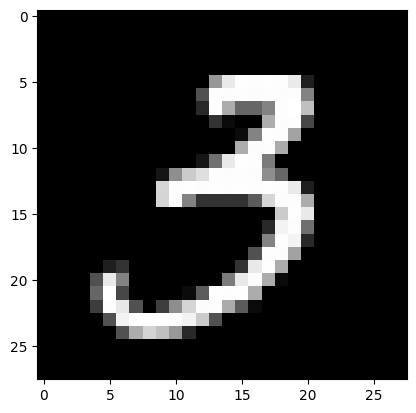

In [63]:
test_prediction(1, W1, b1, W2, b2)